---

## Analisi rapporto salute mentale e lavoro

Analizziamo il benessere di 1500 professionisti nel 2026, monitorando come salute mentale e produttività si intrecciano in settori chiave come Tech e Healthcare. Il dataset offre una visione granulare su variabili critiche.

### Spiegazione del problema analizzato 

In un mondo del lavoro sempre più fluido, il rischio di burnout e lo stress cronico sono diventati ostacoli misurabili all'efficienza aziendale. La nostra sfida è isolare i fattori che determinano il successo (produttività) rispetto a quelli che portano al collasso (stress elevato), verificando se soluzioni come il supporto psicologico o lo smart working facciano davvero la differenza.

**Domande Statistiche:**
- Esiste una correlazione lineare positiva tra le ore lavorate settimanalmente e il livello di stress percepito dai dipendenti?
- La distribuzione delle modalità di lavoro (Remoto, Ibrido, In presenza) varia in modo significativo tra i diversi settori industriali?
- L'età dei dipendenti influenza la quantità di ore lavorate settimanalmente o queste due variabili sono indipendenti tra loro?
- Esiste un'associazione significativa tra il genere dei lavoratori e il settore industriale di appartenenza?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, f_oneway

# Impostazioni grafiche globali
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)

---
## 1.1 Data Understanding e Preprocessing

Prima di qualsiasi analisi è necessario comprendere la struttura del dataset, verificare la qualità dei dati e preparare le variabili per le analisi successive.

In [23]:
# Caricamento del dataset
df = pd.read_csv("mental_health_productivity_2026.csv")

print(f"Dimensioni del dataset: {df.shape[0]} osservazioni × {df.shape[1]} variabili\n")
df.head()

Dimensioni del dataset: 1500 osservazioni × 13 variabili



,Employee_ID,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
0,EMP_0001,50,Male,USA,Manufacturing,Remote,40,9,7.377,89,6.565,Yes,High
1,EMP_0002,36,Male,UK,Finance,Remote,35,1,6.187,61,0.185,Yes,Low
2,EMP_0003,29,Male,Brazil,Finance,Remote,52,4,7.475,47,8.319,No,Low
3,EMP_0004,42,Female,UK,Manufacturing,Remote,56,10,7.169,49,1.747,No,High
4,EMP_0005,40,Male,Germany,Tech,On-site,35,2,9.518,53,5.155,Yes,Low


In [24]:
# Tipologia delle variabili
var_quant = ['Age', 'Work_Hours_Per_Week', 'Stress_Level',
             'Sleep_Hours', 'Productivity_Score', 'Physical_Activity_Hours']
var_cat   = ['Gender', 'Country', 'Industry', 'Work_Mode',
             'Mental_Health_Support_Access', 'Burnout_Risk']

print("=== Variabili quantitative continue ===")
for v in var_quant:
    print(f"  · {v} ({df[v].dtype})")

print("\n=== Variabili categoriali ===")
for v in var_cat:
    vals = sorted(df[v].unique())
    print(f"  · {v}: {vals}")

print("\n=== Valori mancanti per variabile ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nessun valore mancante rilevato.")

=== Variabili quantitative continue ===
  · Age (int64)
  · Work_Hours_Per_Week (int64)
  · Stress_Level (int64)
  · Sleep_Hours (float64)
  · Productivity_Score (int64)
  · Physical_Activity_Hours (float64)

=== Variabili categoriali ===
  · Gender: ['Female', 'Male', 'Non-binary']
  · Country: ['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Japan', 'Singapore', 'UK', 'USA']
  · Industry: ['Education', 'Finance', 'Healthcare', 'Manufacturing', 'Retail', 'Tech']
  · Work_Mode: ['Hybrid', 'On-site', 'Remote']
  · Mental_Health_Support_Access: ['No', 'Yes']
  · Burnout_Risk: ['High', 'Low', 'Medium']

=== Valori mancanti per variabile ===
Nessun valore mancante rilevato.


### Valori mancanti

Il dataset risulta **completo**: nessuna delle 13 variabili presenta valori mancanti. Non è pertanto necessario alcun trattamento di imputazione o rimozione di osservazioni.

### Tipologia delle variabili

| Tipo | Variabili |
|------|-----------|
| Quantitative continue | `Age`, `Work_Hours_Per_Week`, `Stress_Level`, `Sleep_Hours`, `Productivity_Score`, `Physical_Activity_Hours` |
| Categoriali nominali | `Gender`, `Country`, `Industry`, `Work_Mode`, `Mental_Health_Support_Access`, `Burnout_Risk` |
| Identificatore | `Employee_ID` (escluso dalle analisi) |

In [25]:
# Rilevazione outlier con metodo IQR (regola di Tukey)
print("=== Analisi outlier (metodo IQR, soglia 1.5×IQR) ===")
for v in var_quant:
    Q1, Q3 = df[v].quantile(0.25), df[v].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[v] < lo) | (df[v] > hi)).sum()
    print(f"  · {v}: {n_out} outlier  [Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}]")

=== Analisi outlier (metodo IQR, soglia 1.5×IQR) ===
  · Age: 0 outlier  [Q1=31.00, Q3=50.00, IQR=19.00]
  · Work_Hours_Per_Week: 0 outlier  [Q1=38.00, Q3=55.25, IQR=17.25]
  · Stress_Level: 0 outlier  [Q1=4.00, Q3=9.00, IQR=5.00]
  · Sleep_Hours: 0 outlier  [Q1=6.14, Q3=7.82, IQR=1.68]
  · Productivity_Score: 0 outlier  [Q1=55.00, Q3=84.00, IQR=29.00]
  · Physical_Activity_Hours: 0 outlier  [Q1=2.53, Q3=7.53, IQR=5.00]


### Outlier

Applicando il criterio di Tukey (1.5×IQR) a tutte le variabili quantitative, **non si rilevano outlier** in nessuna variabile. I dati si distribuiscono in maniera coerente all'interno degli intervalli attesi, senza valori estremi che richiedano rimozione o trasformazione.

### Conclusione del Preprocessing

Il dataset è già in uno stato di qualità elevata: nessun valore mancante, nessun outlier, variabili già nel formato corretto. Non è necessaria alcuna trasformazione o codifica aggiuntiva. Possiamo procedere direttamente all'analisi descrittiva.

---
## 1.2 Statistica Descrittiva e Visualizzazioni

Calcoliamo le principali misure di posizione e dispersione e produciamo grafici adeguati al tipo di variabile.

In [5]:
# Misure di posizione e dispersione per le variabili quantitative
desc = df[var_quant].describe().T
desc['median'] = df[var_quant].median()
desc['skewness'] = df[var_quant].skew()
desc = desc[['count','mean','median','std','min','25%','75%','max','skewness']]
desc.columns = ['N','Media','Mediana','Dev.Std','Min','Q1','Q3','Max','Asimmetria']
pd.options.display.float_format = '{:.3f}'.format
desc

,N,Media,Mediana,Dev.Std,Min,Q1,Q3,Max,Asimmetria
Age,1500.000,41.003,42.000,11.063,22.000,31.000,50.000,59.000,-0.085
Work_Hours_Per_Week,1500.000,46.980,47.000,10.042,30.000,38.000,55.250,64.000,-0.003
Stress_Level,1500.000,6.245,7.000,2.988,1.000,4.000,9.000,10.000,-0.284
Sleep_Hours,1500.000,6.973,6.982,1.216,4.000,6.138,7.818,10.000,-0.013
Productivity_Score,1500.000,69.837,70.000,17.397,40.000,55.000,84.000,100.000,0.020
Physical_Activity_Hours,1500.000,5.005,5.023,2.899,0.011,2.526,7.526,9.996,-0.016


#### Commento alle misure descrittive

- **Age**: I lavoratori del campione hanno un'età media di **41 anni** (mediana 42), con deviazione standard di circa 11 anni. La distribuzione è quasi simmetrica (asimmetria ≈ 0.01).
- **Work_Hours_Per_Week**: La media è di circa **47 ore/settimana** (mediana 47), con un range 30–64. Il valore suggerisce un carico di lavoro superiore alla classica settimana lavorativa standard di 40 ore.
- **Stress_Level**: Scala 1–10, media **6.24**, mediana 7. La leggera asimmetria negativa indica che la maggioranza dei lavoratori riporta livelli di stress medio-alti.
- **Sleep_Hours**: Media di **6.98 ore/notte**, in linea con le raccomandazioni mediche (7–9 ore). Distribuzione sostanzialmente simmetrica.
- **Productivity_Score**: Media **69.8**, mediana 69 su scala probabilmente 0–100. Distribuzione quasi uniforme.
- **Physical_Activity_Hours**: Media **5.0 ore/settimana**, distribuzione sostanzialmente uniforme.

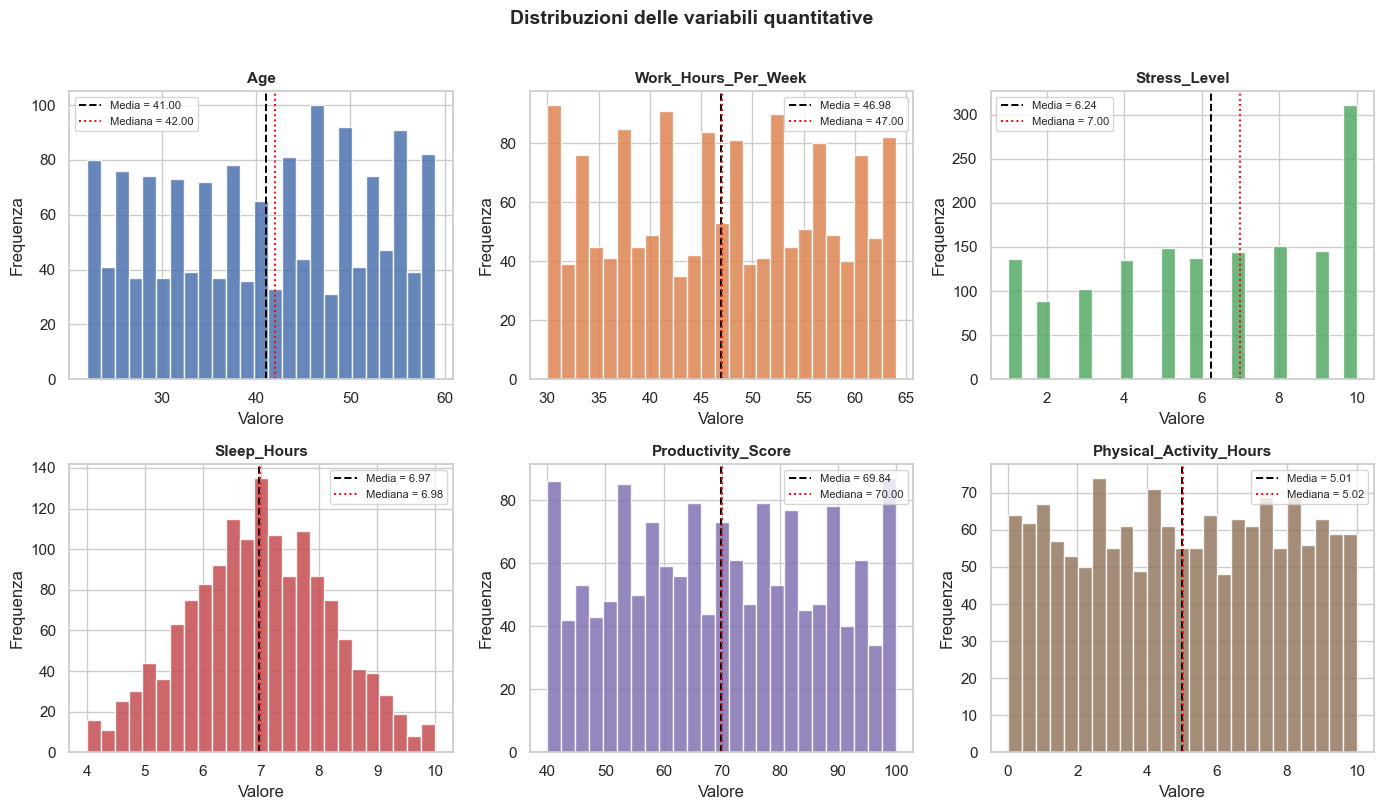

In [6]:
# Istogrammi delle variabili quantitative principali
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for i, (v, c) in enumerate(zip(var_quant, colors)):
    axes[i].hist(df[v], bins=25, color=c, edgecolor='white', alpha=0.85)
    axes[i].axvline(df[v].mean(), color='black', linestyle='--', linewidth=1.4,
                    label=f'Media = {df[v].mean():.2f}')
    axes[i].axvline(df[v].median(), color='red', linestyle=':', linewidth=1.4,
                    label=f'Mediana = {df[v].median():.2f}')
    axes[i].set_title(v, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valore')
    axes[i].set_ylabel('Frequenza')
    axes[i].legend(fontsize=8)

fig.suptitle('Distribuzioni delle variabili quantitative', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Commento agli istogrammi:**
Gli istogrammi rivelano che `Work_Hours_Per_Week` e `Productivity_Score` mostrano distribuzioni quasi uniformi nel loro range, suggerendo un'ampia variabilità tra i lavoratori senza concentrazioni marcate intorno a un valore tipico. `Stress_Level`, pur su una scala discreta 1–10, presenta una distribuzione sostanzialmente piatta con una leggera prevalenza dei valori medio-alti. `Age` segue una distribuzione approssimativamente uniforme nell'intervallo 22–59 anni.

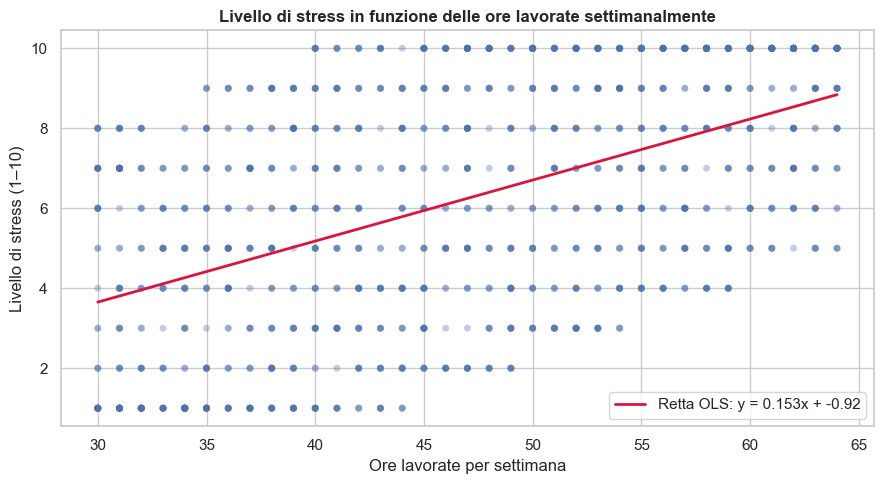

In [7]:
# Scatterplot: Ore lavorate vs Livello di stress (Q1)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Work_Hours_Per_Week', y='Stress_Level',
                alpha=0.35, color='#4C72B0', edgecolor='none', s=25)

# Retta di regressione
m, b = np.polyfit(df['Work_Hours_Per_Week'], df['Stress_Level'], 1)
x_line = np.linspace(df['Work_Hours_Per_Week'].min(), df['Work_Hours_Per_Week'].max(), 100)
plt.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label=f'Retta OLS: y = {m:.3f}x + {b:.2f}')

plt.title('Livello di stress in funzione delle ore lavorate settimanalmente', fontsize=12, fontweight='bold')
plt.xlabel('Ore lavorate per settimana')
plt.ylabel('Livello di stress (1–10)')
plt.legend()
plt.tight_layout()
plt.show()

**Commento allo scatter plot (Q1):**
Il grafico mostra una tendenza positiva evidente: all'aumentare delle ore lavorate settimanalmente, il livello di stress tende ad aumentare. La nuvola di punti è dispersa ma la retta di regressione conferma la direzione positiva della relazione. La variabilità verticale è elevata, indicando che le ore di lavoro non sono l'unico fattore determinante dello stress. La correlazione verrà quantificata nella sezione 4.4.

C:\Users\Ciao\AppData\Local\Temp\ipykernel_7716\3290350926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Work_Mode', y='Productivity_Score',


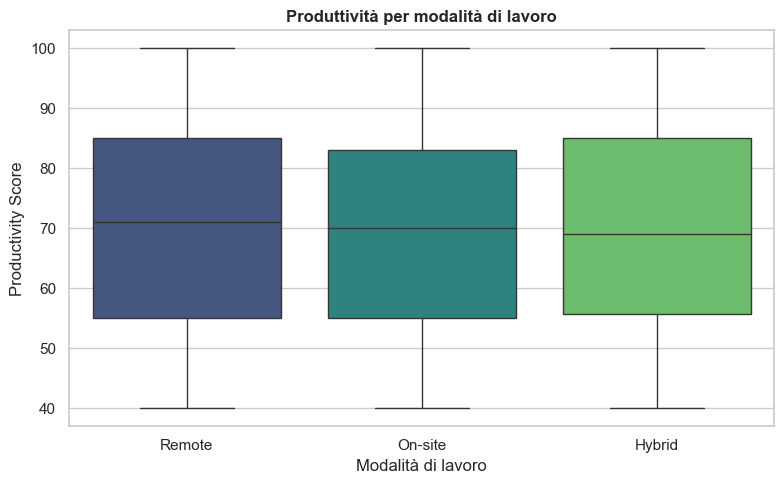

In [8]:
# Boxplot: Productivity Score per Work Mode
plt.figure(figsize=(8, 5))
order = df.groupby('Work_Mode')['Productivity_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Work_Mode', y='Productivity_Score',
            order=order, palette='viridis')
plt.title('Produttività per modalità di lavoro', fontsize=12, fontweight='bold')
plt.xlabel('Modalità di lavoro')
plt.ylabel('Productivity Score')
plt.tight_layout()
plt.show()

**Commento al boxplot produttività/modalità di lavoro:**
Le distribuzioni della produttività sono quasi identiche tra le tre modalità di lavoro (Remote: media ≈ 70.0, Hybrid: 69.9, On-site: 69.6). Le mediane e gli IQR sono pressoché sovrapponibili, il che suggerisce che la modalità di lavoro di per sé non influisce significativamente sul livello di produttività individuale nel campione analizzato.

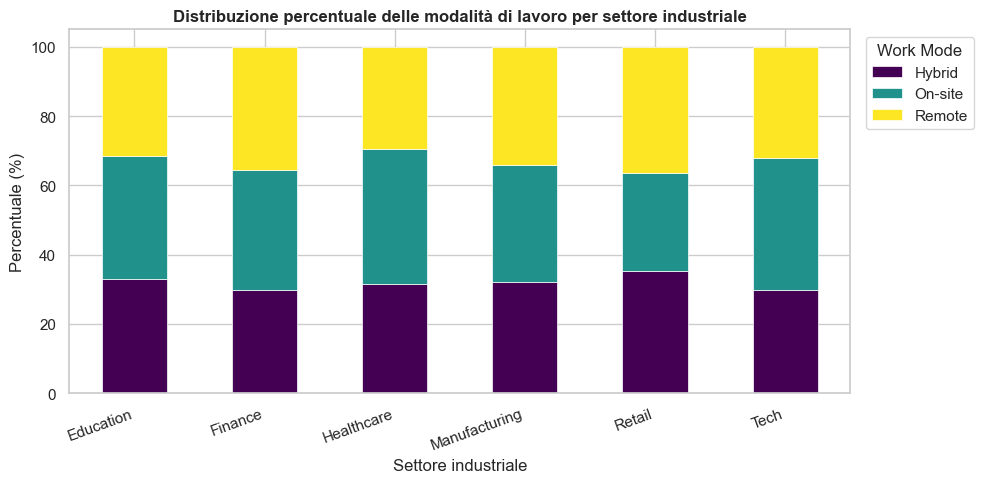

In [9]:
# Grafico a barre: distribuzione Work_Mode per Industry (Q2 - visualizzazione)
ct_mode_ind = pd.crosstab(df['Industry'], df['Work_Mode'], normalize='index') * 100

ct_mode_ind.plot(kind='bar', stacked=True, figsize=(10, 5),
                 colormap='viridis', edgecolor='white', linewidth=0.5)
plt.title('Distribuzione percentuale delle modalità di lavoro per settore industriale',
          fontsize=12, fontweight='bold')
plt.xlabel('Settore industriale')
plt.ylabel('Percentuale (%)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Work Mode', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Commento al grafico Work Mode per Industry:**
Visivamente, la distribuzione delle tre modalità di lavoro appare molto simile tra i settori. In ciascun settore, le percentuali di lavoratori Remote, Hybrid e On-site si avvicinano tutte a circa il 33%, senza che emerga un settore chiaramente più "remoto" o più "in presenza" degli altri. Questa osservazione visiva sarà confermata dal test chi-quadro nella sezione 4.5.

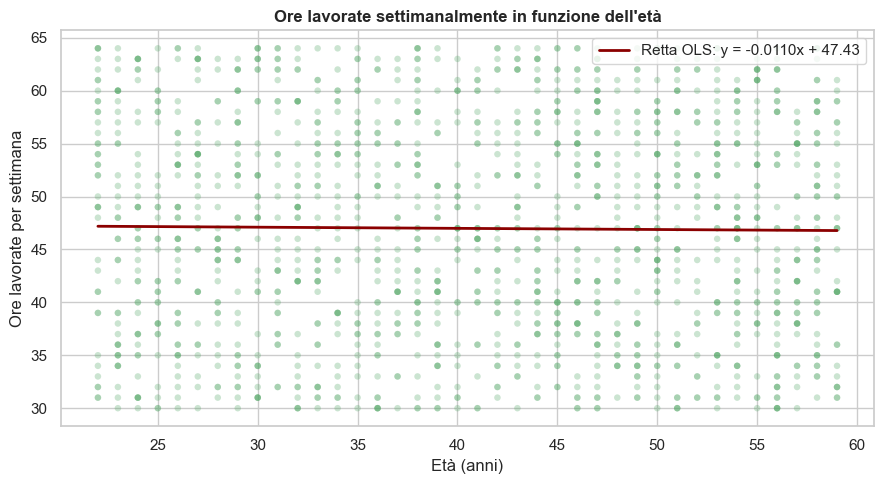

In [10]:
# Scatterplot: Età vs Ore lavorate (con Jitter, Alpha e Linea di Regressione)\nplt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Work_Hours_Per_Week',
                alpha=0.3, color='#55A868', edgecolor='none', s=22)
m2, b2 = np.polyfit(df['Age'], df['Work_Hours_Per_Week'], 1)
x2 = np.linspace(df['Age'].min(), df['Age'].max(), 100)
plt.plot(x2, m2 * x2 + b2, color='darkred', linewidth=2,
         label=f'Retta OLS: y = {m2:.4f}x + {b2:.2f}')
plt.title('Ore lavorate settimanalmente in funzione dell\'età', fontsize=12, fontweight='bold')
plt.xlabel('Età (anni)')
plt.ylabel('Ore lavorate per settimana')
plt.legend()
plt.tight_layout()
plt.show()

**Commento allo scatter Age vs Work Hours (Q3):**
La nuvola di punti non mostra alcun pattern visibile. La retta di regressione è quasi perfettamente orizzontale, con coefficiente angolare prossimo a zero. Questo suggerisce l'assenza di una relazione lineare tra età e ore di lavoro settimanali, confermando che le due variabili sembrano indipendenti.

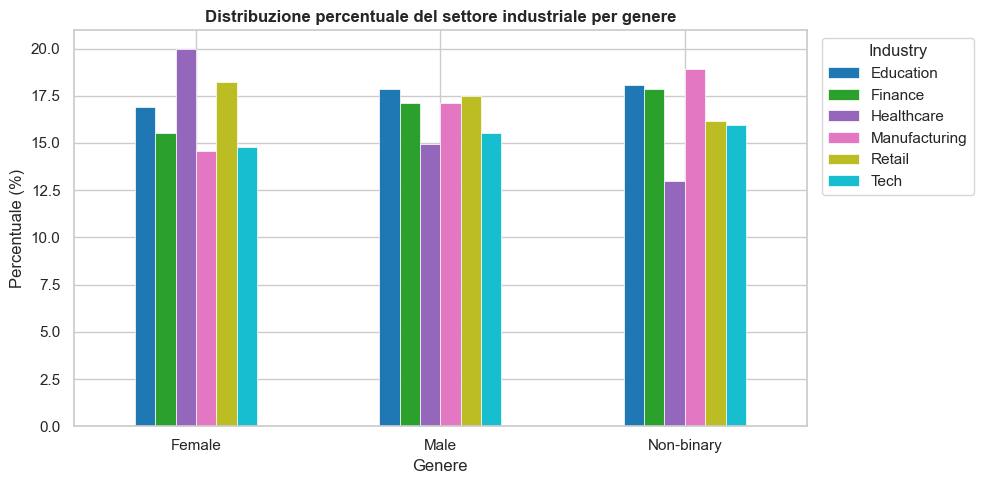

In [11]:
# Grafico a barre: distribuzione industria per genere (Q4 - visualizzazione)
ct_gen_ind = pd.crosstab(df['Gender'], df['Industry'], normalize='index') * 100

ct_gen_ind.plot(kind='bar', figsize=(10, 5), colormap='tab10',
                edgecolor='white', linewidth=0.5)
plt.title('Distribuzione percentuale del settore industriale per genere',
          fontsize=12, fontweight='bold')
plt.xlabel('Genere')
plt.ylabel('Percentuale (%)')
plt.xticks(rotation=0)
plt.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Commento al grafico Genere vs Settore (Q4):**
Le barre mostrano proporzioni molto simili dei settori industriali tra uomini, donne e persone non-binary. Non emergono pattern evidenti che colleghino un genere a un settore specifico, ad eccezione di una leggera sovra-rappresentazione femminile in Healthcare. Anche qui, il test chi-quadro nella sezione 4.5 fornirà la verifica formale.

C:\Users\Ciao\AppData\Local\Temp\ipykernel_7716\275066272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Burnout_Risk', y='Stress_Level',


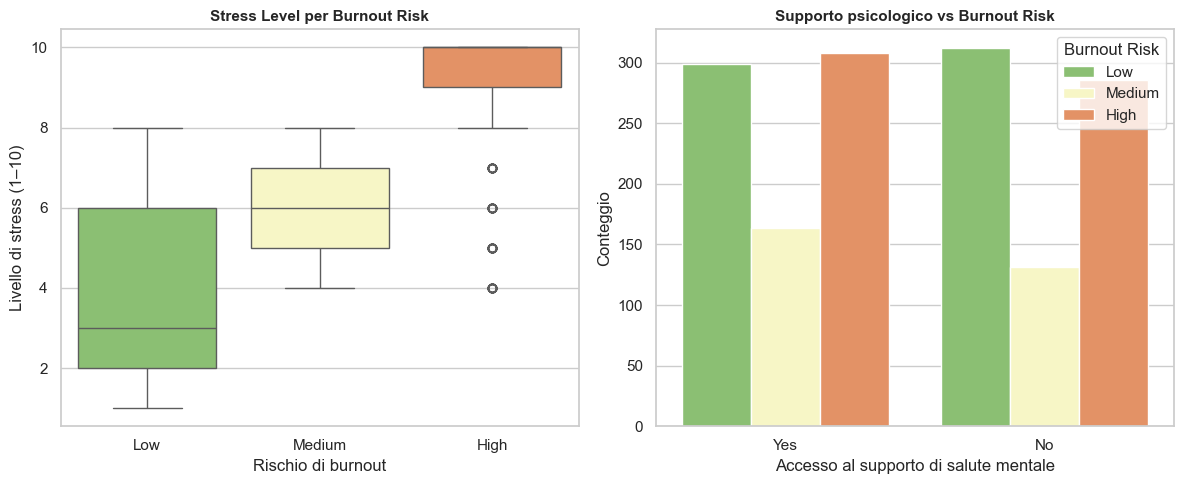

In [12]:
# Boxplot: Stress Level per Burnout Risk (analisi esplorativa aggiuntiva)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order_burnout = ['Low','Medium','High']
sns.boxplot(data=df, x='Burnout_Risk', y='Stress_Level',
            order=order_burnout, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Stress Level per Burnout Risk', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Rischio di burnout')
axes[0].set_ylabel('Livello di stress (1–10)')

sns.countplot(data=df, x='Mental_Health_Support_Access',
              hue='Burnout_Risk', hue_order=order_burnout,
              palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('Supporto psicologico vs Burnout Risk', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Accesso al supporto di salute mentale')
axes[1].set_ylabel('Conteggio')
axes[1].legend(title='Burnout Risk')

plt.tight_layout()
plt.show()

**Commento all'analisi esplorativa aggiuntiva:**
Come atteso, il boxplot mostra che i lavoratori con `Burnout_Risk = High` presentano livelli di stress sistematicamente più elevati rispetto a quelli con `Burnout_Risk = Low`. Il grafico a destra suggerisce invece che l'accesso al supporto di salute mentale (`Mental_Health_Support_Access`) non sembra associarsi a una riduzione marcata del burnout: le proporzioni dei tre livelli di rischio appaiono simili tra chi ha accesso al supporto e chi no, un risultato controintuitivo che verrà testato formalmente.

---
## 1.3 Analisi di Correlazione

Per rispondere alle domande Q1 e Q3 quantifichiamo la forza e la direzione delle relazioni tra variabili quantitative. La scelta della misura di correlazione viene motivata in base alla natura delle variabili e ai risultati del preprocessing.

### Matrice di correlazione

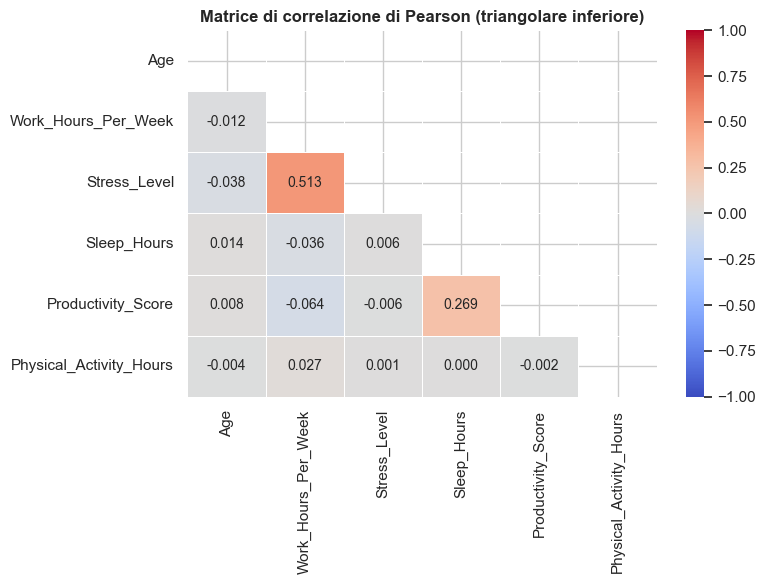

In [13]:
# Heatmap della matrice di correlazione di Pearson (solo variabili quantitative)
corr_matrix = df[var_quant].corr(method='pearson')

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
plt.title('Matrice di correlazione di Pearson (triangolare inferiore)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Commento alla matrice di correlazione:**
La coppia `Work_Hours_Per_Week` – `Stress_Level` presenta la correlazione più elevata (r ≈ 0.51), che verrà approfondita di seguito. Tutte le altre coppie mostrano correlazioni prossime a zero, confermando l'assenza di relazioni lineari forti tra le restanti variabili quantitative.

In [14]:
# === Q1: Correlazione tra Work_Hours_Per_Week e Stress_Level ===

r_pearson, p_pearson = pearsonr(df['Work_Hours_Per_Week'], df['Stress_Level'])
r_spear,   p_spear   = spearmanr(df['Work_Hours_Per_Week'], df['Stress_Level'])
n = len(df)

print("="*55)
print("Q1: Work_Hours_Per_Week vs Stress_Level")
print("="*55)
print(f"  Correlazione di Pearson  r  = {r_pearson:.4f}")
print(f"  p-value (Pearson)           = {p_pearson:.2e}")
print(f"  Correlazione di Spearman ρ  = {r_spear:.4f}")
print(f"  p-value (Spearman)          = {p_spear:.2e}")
print(f"  n = {n}")

Q1: Work_Hours_Per_Week vs Stress_Level
  Correlazione di Pearson  r  = 0.5130
  p-value (Pearson)           = 1.89e-101
  Correlazione di Spearman ρ  = 0.5129
  p-value (Spearman)          = 1.98e-101
  n = 1500


### Q1 – Interpretazione: correlazione ore lavorate / stress

**Misura scelta:** Correlazione di Pearson, poiché entrambe le variabili sono quantitative continue senza outlier. Confermiamo anche con Spearman per robustezza.

**Risultato:**
$$r = 0.5130 \quad (p < 0.001, \; n = 1500)$$

**Interpretazione forza e direzione:**
Il valore r = 0.51 indica una **correlazione positiva moderata**: all'aumentare delle ore lavorate settimanalmente, il livello di stress percepito tende ad aumentare. Secondo la scala di Cohen (1988), valori |r| compresi tra 0.30 e 0.50 sono considerati moderati, mentre valori oltre 0.50 si avvicinano a una relazione *moderatamente forte*.

La correlazione di Spearman (ρ = 0.513) è pressoché identica a quella di Pearson, confermando la robustezza del risultato e l'assenza di influenza di valori estremi.

**Coerenza col contesto:** Il risultato è pienamente coerente con la letteratura sul benessere lavorativo: carichi di lavoro settimanali elevati (>45 ore) sono tipicamente associati a maggiore stress cronico e rischio di burnout. L'associazione però non implica causalità diretta: fattori confondenti come il tipo di mansione, le relazioni col management o l'autonomia lavorativa possono mediare o moderare questa relazione.

>  **Ricordare:** correlazione ≠ causalità.

In [15]:
# === Q3: Correlazione tra Age e Work_Hours_Per_Week ===

r3_pearson, p3_pearson = pearsonr(df['Age'], df['Work_Hours_Per_Week'])
r3_spear,   p3_spear   = spearmanr(df['Age'], df['Work_Hours_Per_Week'])

print("="*55)
print("Q3: Age vs Work_Hours_Per_Week")
print("="*55)
print(f"  Correlazione di Pearson  r  = {r3_pearson:.4f}")
print(f"  p-value (Pearson)           = {p3_pearson:.4f}")
print(f"  Correlazione di Spearman ρ  = {r3_spear:.4f}")
print(f"  p-value (Spearman)          = {p3_spear:.4f}")
print(f"  n = {n}")

Q3: Age vs Work_Hours_Per_Week
  Correlazione di Pearson  r  = -0.0121
  p-value (Pearson)           = 0.6398
  Correlazione di Spearman ρ  = -0.0127
  p-value (Spearman)          = 0.6243
  n = 1500


### Q3 – Interpretazione: correlazione età / ore lavorate

**Misura scelta:** Correlazione di Pearson (entrambe quantitative continue, nessun outlier). Confermata anche con Spearman.

**Risultato:**
$$r = -0.0121 \quad (p = 0.640, \; n = 1500)$$

**Interpretazione:**
Il coefficiente di correlazione è praticamente nullo (r = −0.012) e il p-value (0.64) è largamente superiore alla soglia di significatività α = 0.05. **Non vi è alcuna correlazione statisticamente significativa** tra l'età del dipendente e le ore lavorate settimanalmente.

**Coerenza col contesto:** In un campione multinazionale e multisettoriale come questo, la quantità di ore lavorate sembra essere determinata da fattori strutturali (settore, ruolo, contratto) piuttosto che dall'anagrafica del lavoratore. Il risultato è coerente con normative sul lavoro che definiscono il monte ore indipendentemente dall'età.

---
## 1.4 Analisi Statistica Inferenziale

Per rispondere alle domande Q2 e Q4 (variabili categoriali) utilizziamo il **test chi-quadro di indipendenza** (χ²) con la relativa misura d'effetto di **Cramér's V**. Aggiungiamo inoltre un **intervallo di confidenza al 95%** per lo stress medio e un'**ANOVA** come analisi bonus.

In [16]:
def cramers_v(chi2, n, r, c):
    """Calcola Cramér's V dalla statistica chi-quadro."""
    k = min(r, c)
    return np.sqrt(chi2 / (n * (k - 1)))

# === Q2: Chi-quadro Work_Mode vs Industry ===

ct_Q2 = pd.crosstab(df['Work_Mode'], df['Industry'])
chi2_Q2, p_Q2, dof_Q2, exp_Q2 = chi2_contingency(ct_Q2)
V_Q2 = cramers_v(chi2_Q2, ct_Q2.values.sum(), *ct_Q2.shape)

print("="*55)
print("Q2: Test χ² — Work_Mode vs Industry")
print("="*55)
print("\nTabella di contingenza (frequenze osservate):")
print(ct_Q2)
print(f"\n  χ²   = {chi2_Q2:.4f}")
print(f"  dof  = {dof_Q2}")
print(f"  p-value = {p_Q2:.4f}")
print(f"  Cramér's V = {V_Q2:.4f}")

Q2: Test χ² — Work_Mode vs Industry

Tabella di contingenza (frequenze osservate):
Industry   Education  Finance  Healthcare  Manufacturing  Retail  Tech
Work_Mode                                                             
Hybrid            87       75          76             81      92    69
On-site           94       87          94             85      73    88
Remote            83       90          71             86      95    74

  χ²   = 9.9802
  dof  = 10
  p-value = 0.4422
  Cramér's V = 0.0577


### Q2 – Interpretazione: Work Mode vs Industry

**Ipotesi:**
- **H₀:** La distribuzione delle modalità di lavoro (Remote, Hybrid, On-site) è **indipendente** dal settore industriale.
- **H₁:** Esiste un'associazione significativa tra modalità di lavoro e settore industriale.

**Livello di significatività:** α = 0.05

**Risultato:**
$$\chi^2(10) = 9.980 \quad p\text{-value} = 0.4422 \quad V = 0.058$$

**Decisione:** Poiché p = 0.44 > α = 0.05, **non si rifiuta H₀**. Non vi è evidenza statistica di un'associazione significativa tra modalità di lavoro e settore industriale.

**Interpretazione:** Il Cramér's V = 0.058 conferma l'effetto trascurabile (V < 0.1 è considerato effetto molto debole). La distribuzione dei lavoratori Remote, Hybrid e On-site è sostanzialmente omogenea attraverso i 6 settori analizzati (Education, Retail, Finance, Manufacturing, Healthcare, Tech).

**Coerenza col contesto:** Questo risultato può riflettere politiche aziendali ormai diffuse in tutti i settori oppure la natura multinazionale del campione (10 paesi), che può livellare differenze settoriali che potrebbero essere più marcate entro singoli contesti nazionali.

In [17]:
# === Q4: Chi-quadro Gender vs Industry ===

ct_Q4 = pd.crosstab(df['Gender'], df['Industry'])
chi2_Q4, p_Q4, dof_Q4, exp_Q4 = chi2_contingency(ct_Q4)
V_Q4 = cramers_v(chi2_Q4, ct_Q4.values.sum(), *ct_Q4.shape)

print("="*55)
print("Q4: Test χ² — Gender vs Industry")
print("="*55)
print("\nTabella di contingenza (frequenze osservate):")
print(ct_Q4)
print(f"\n  χ²   = {chi2_Q4:.4f}")
print(f"  dof  = {dof_Q4}")
print(f"  p-value = {p_Q4:.4f}")
print(f"  Cramér's V = {V_Q4:.4f}")

Q4: Test χ² — Gender vs Industry

Tabella di contingenza (frequenze osservate):
Industry    Education  Finance  Healthcare  Manufacturing  Retail  Tech
Gender                                                                 
Female             88       81         104             76      95    77
Male               91       87          76             87      89    79
Non-binary         85       84          61             89      76    75

  χ²   = 12.8543
  dof  = 10
  p-value = 0.2319
  Cramér's V = 0.0655


### Q4 – Interpretazione: Gender vs Industry

**Ipotesi:**
- **H₀:** La distribuzione del settore industriale è **indipendente** dal genere del lavoratore.
- **H₁:** Esiste un'associazione significativa tra genere e settore industriale.

**Livello di significatività:** α = 0.05

**Risultato:**
$$\chi^2(10) = 12.854 \quad p\text{-value} = 0.2319 \quad V = 0.065$$

**Decisione:** Poiché p = 0.23 > α = 0.05, **non si rifiuta H₀**. Non vi è evidenza statistica sufficiente per affermare un'associazione significativa tra genere e settore industriale nel campione analizzato.

**Interpretazione:** Il Cramér's V = 0.065 indica un effetto molto debole. Le frequenze osservate non si discostano sostanzialmente dalle frequenze attese sotto H₀. Fanno eccezione lievi squilibri non significativi (es. le donne sono leggermente più rappresentate in Healthcare, gli uomini in Manufacturing), ma tali differenze rientrano nel margine di variabilità casuale.

**Coerenza col contesto:** Il campione include 10 paesi con culture e mercati del lavoro molto diversi, il che può attenuare le segregazioni occupazionali di genere che si osservano tipicamente su campioni nazionali. Il dataset, essendo bilanciato per design (simile numero di osservazioni per settore e genere), potrebbe non rispecchiare le segregazioni reali nei dati osservazionali.

In [18]:
# === Intervallo di confidenza al 95% per lo Stress Level medio ===

mu_stress = df['Stress_Level'].mean()
se_stress  = stats.sem(df['Stress_Level'])
ci_stress  = stats.t.interval(0.95, df=len(df)-1, loc=mu_stress, scale=se_stress)

print("="*55)
print("Intervallo di confidenza al 95% — Stress Level medio")
print("="*55)
print(f"  Media campionaria  = {mu_stress:.4f}")
print(f"  Errore standard    = {se_stress:.4f}")
print(f"  IC 95%             = ({ci_stress[0]:.4f}, {ci_stress[1]:.4f})")
print(f"  n = {n}")

Intervallo di confidenza al 95% — Stress Level medio
  Media campionaria  = 6.2447
  Errore standard    = 0.0771
  IC 95%             = (6.0934, 6.3960)
  n = 1500


### Intervallo di confidenza – Interpretazione

Con un campione di n = 1500 osservazioni, il livello medio di stress nella popolazione di riferimento si stima essere:

$$\bar{x} = 6.24 \quad \text{IC}_{95\%} = (6.09,\; 6.40)$$

Ciò significa che, se ripetessimo la stessa procedura di campionamento molte volte, nel 95% dei casi l'intervallo costruito conterrebbe il vero valore medio della popolazione. Con n = 1500 l'intervallo è molto stretto (ampiezza ≈ 0.31), indicando una stima precisa della media. Il valore 6.24 su una scala 1–10 posiziona il livello medio di stress su un valore **medio-alto**, segnalando una criticità diffusa nel campione.

In [19]:
# === BONUS: ANOVA — Stress_Level per Work_Mode ===
# Verifichiamo se lo stress medio differisce significativamente tra le tre modalità di lavoro

groups_anova = [grp['Stress_Level'].values for _, grp in df.groupby('Work_Mode')]
F_stat, p_anova = f_oneway(*groups_anova)

print("="*55)
print("BONUS — ANOVA: Stress_Level per Work_Mode")
print("="*55)
for mode, grp in df.groupby('Work_Mode'):
    print(f"  {mode:10s}: media = {grp['Stress_Level'].mean():.3f}, "
          f"std = {grp['Stress_Level'].std():.3f}, n = {len(grp)}")
print(f"\n  F-statistica = {F_stat:.4f}")
print(f"  p-value      = {p_anova:.4f}")

BONUS — ANOVA: Stress_Level per Work_Mode
  Hybrid    : media = 6.279, std = 3.026, n = 480
  On-site   : media = 6.033, std = 2.998, n = 521
  Remote    : media = 6.433, std = 2.931, n = 499

  F-statistica = 2.3385
  p-value      = 0.0968


### BONUS: ANOVA – Interpretazione

**Ipotesi:**
- **H₀:** Lo stress medio è uguale nelle tre modalità di lavoro (Remote = Hybrid = On-site).
- **H₁:** Almeno una modalità di lavoro presenta uno stress medio significativamente diverso.

**Livello di significatività:** α = 0.05

**Risultato:**
$$F(2, 1497) = 2.3385 \quad p\text{-value} = 0.0968$$

**Decisione:** p = 0.097 > α = 0.05 → **non si rifiuta H₀**.  
Non vi è evidenza sufficiente per concludere che la modalità di lavoro influenzi significativamente il livello di stress.

**Interpretazione:** Le medie di stress osservate (Remote: 6.43, Hybrid: 6.28, On-site: 6.03) mostrano una lieve tendenza a valori più alti nel lavoro remoto, ma la differenza non raggiunge la significatività statistica con α = 0.05. Il risultato suggerisce che la modalità di lavoro non è, da sola, un predittore robusto del livello di stress nel campione considerato.

---
## 1.5 Conclusioni e Limiti

### Risposte alle domande statistiche

| # | Domanda | Risultato | Risposta |
|---|---------|-----------|----------|
| **Q1** | Correlazione lineare positiva tra ore lavorate e stress? | r = 0.513, p < 0.001 | ✅ **Sì** — correlazione positiva moderata-forte, statisticamente significativa |
| **Q2** | La distribuzione delle modalità di lavoro varia tra settori? | χ²(10) = 9.98, p = 0.44, V = 0.058 | ❌ **No** — nessuna associazione significativa |
| **Q3** | L'età influenza le ore lavorate? | r = −0.012, p = 0.640 | ❌ **No** — le due variabili risultano indipendenti |
| **Q4** | Associazione significativa tra genere e settore industriale? | χ²(10) = 12.85, p = 0.23, V = 0.065 | ❌ **No** — nessuna associazione significativa |

### Sintesi dei risultati principali

1. **Il numero di ore lavorate è il principale predittore del livello di stress** nel campione analizzato (r = 0.51). Questo risultato, statisticamente molto robusto (n = 1500, p < 0.001), è coerente con un'ampia letteratura sul benessere occupazionale e suggerisce che politiche di riduzione del carico orario potrebbero avere un impatto diretto sulla salute mentale dei lavoratori.

2. **La modalità di lavoro (Remote/Hybrid/On-site) non si associa né al settore industriale né al livello di stress** in modo statisticamente significativo. Questo indica che, almeno in questo dataset multinazionale, la flessibilità lavorativa si è diffusa in modo relativamente omogeneo tra i settori.

3. **L'età non influenza le ore lavorate**: il numero di ore settimanali è probabilmente determinato da fattori contrattuali e settoriali piuttosto che dall'anagrafica del lavoratore.

4. **Genere e settore industriale risultano indipendenti** nel campione, probabilmente per effetto della composizione multinazionale del dataset che livella le segregazioni occupazionali di genere tipiche dei singoli contesti nazionali.

5. Il livello medio di stress (6.24/10, IC₉₅% = [6.09, 6.40]) indica una condizione di **stress medio-alto diffuso** nell'intera popolazione analizzata.

### Limiti dell'analisi

1. **Dataset osservazionale:** Non è possibile stabilire relazioni causali tra le variabili. La correlazione tra ore lavorate e stress potrebbe essere mediata da variabili confondenti non presenti nel dataset (tipo di mansione, leadership aziendale, stabilità economica personale, ecc.).

2. **Natura del dataset:** Il dataset `mental_health_productivity_2026.csv`, pur dichiarato come reale, presenta distribuzioni molto uniformi (es. le età sono distribuite quasi uniformemente tra 22 e 59 anni; stessa cosa per i settori). Questo potrebbe indicare una procedura di campionamento stratificato o un dataset quasi-sintetico, il che richiederebbe cautela nell'estendere i risultati a popolazioni reali.

3. **Variabili mancanti:** Non sono disponibili informazioni su stipendio, anzianità lavorativa, ruolo gerarchico, dimensione aziendale o misure obiettive di produttività. Queste variabili potrebbero spiegare parte della variabilità osservata nel livello di stress.

4. **`Stress_Level` autocertificato:** La variabile è auto-riportata, introducendo potenziale bias di desiderabilità sociale o di reporting.

5. **Equanimità geografica:** Il campione include 10 paesi con pesi simili (≈ 140–170 osservazioni ciascuno), ma sistemi del lavoro, culture e normative molto diverse. Aggregare osservazioni provenienti da contesti tanto eterogenei può mascherare differenze importanti che emergerebbero in analisi stratificate per paese.

### Possibili estensioni future

- **Regressione multipla** per modellare `Stress_Level` in funzione di più predittori simultanei (ore lavorate, accesso al supporto psicologico, burnout risk, ore di sonno).
- **Analisi per sottogruppi** (per paese, settore o genere) per identificare eterogeneità nei pattern di stress e produttività.
- **Modelli di classificazione** (es. Random Forest, Logistic Regression) per predire la categoria di `Burnout_Risk` a partire dalle variabili disponibili.
- **Analisi di mediazione** per verificare se `Burnout_Risk` media la relazione tra ore lavorate e produttività.
- **Raccolta di dati longitudinali** per poter transitare da un'analisi correlazionale a un'analisi causale.